# RelayBP Hyperparameter Tuning

In [1]:
%reload_ext autoreload
%autoreload 2
from math import prod
import os

import matplotlib.pyplot as plt
import numpy as np
from qecdec.circuits import create_circuit_with_uniform_error_rate
from qecdec.decoders import (
    BPDecoder,
    MemBPDecoder,
    MWPMDecoder,
    RelayBPDecoder,
    UnionFindDecoder,
)
from qecdec.sinter_utils import QecdecSinterDecoder
import sinter

Circuit parameters

In [2]:
circuit_name = "RotatedSurfaceCode_Circuit"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}

# Physical error rate at which the decoder is tuned
opt_error_rate = 0.001

opt_circuit = create_circuit_with_uniform_error_rate(
    circuit_name, opt_error_rate, **circuit_params
)

RelayBP decoder parameters

In [3]:
relaybp_params = {
    "num_relays": 16,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}

## Phase 1 — gamma0 sweep

In [4]:
# List of gamma0 values to sweep
membp_gamma0s = np.linspace(0, 1, 21).tolist()

In [5]:
def generate_gamma0_sweep_tasks():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}

    for gamma0 in membp_gamma0s:
        decoder = MemBPDecoder(
            opt_circuit.chkmat,
            opt_circuit.prior,
            gamma=gamma0,
            max_iter=relaybp_params["pre_iter"],
        )
        custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[custom_decoder_id] = QecdecSinterDecoder(
            decoder, opt_circuit.obsmat
        )
        tasks.append(
            sinter.Task(
                circuit=opt_circuit.stim_circuit,
                detector_error_model=opt_circuit.stim_dem,
                decoder=custom_decoder_id,
                json_metadata={"gamma0": gamma0},
            )
        )
    return tasks, custom_decoders


tasks, custom_decoders = generate_gamma0_sweep_tasks()

In [6]:
gamma0_sweep_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    print_progress=True,
)

Starting 31 workers...
21 tasks left:
  workers           decoder eta shots_left errors_left json_metadata             
        1  custom_decoder_0   ?   10000000         100 gamma0=0.0                
        1  custom_decoder_1   ?   10000000         100 gamma0=0.05               
        1  custom_decoder_2   ?   10000000         100 gamma0=0.1                
        1  custom_decoder_3 98m    9999999         100 gamma0=0.15000000000000002
        1  custom_decoder_4   ?   10000000         100 gamma0=0.2                
        1  custom_decoder_5   ?   10000000         100 gamma0=0.25               
        1  custom_decoder_6   ?   10000000         100 gamma0=0.30000000000000004
        1  custom_decoder_7   ?   10000000         100 gamma0=0.35000000000000003
        1  custom_decoder_8   ?   10000000         100 gamma0=0.4                
        1  custom_decoder_9   ?   10000000         100 gamma0=0.45               
        1 custom_decoder_10   ?   10000000         100 gamma

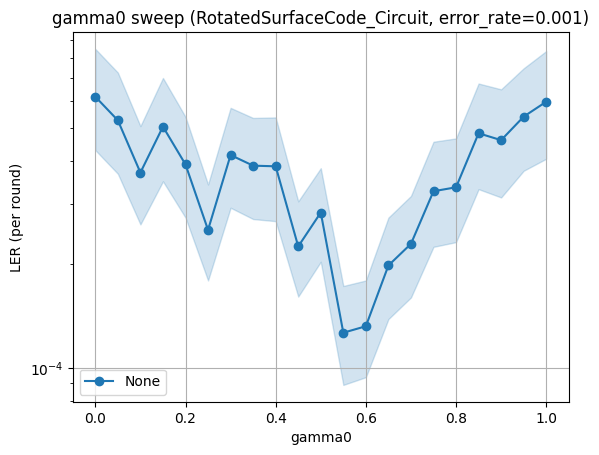

In [7]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=gamma0_sweep_stats,
    failure_units_per_shot_func=lambda _: circuit_params["rounds"],
    x_func=lambda stat: stat.json_metadata["gamma0"],
)
ax.semilogy()
ax.grid()
ax.set_ylabel("LER (per round)")
ax.set_xlabel("gamma0")
ax.set_title(f"gamma0 sweep ({circuit_name}, error_rate={opt_error_rate})")
ax.legend()

plt.show()

In [8]:
gamma0_star = min((stats.errors/stats.shots, stats.json_metadata["gamma0"]) for stats in gamma0_sweep_stats)[1]
print(f"Optimal gamma0: {gamma0_star}")

Optimal gamma0: 0.55


## Phase 2 — Optimization of gamma_dist_interval

In [9]:
import nevergrad as ng

opt_budget = 100
opt_raw_shots = 800_000


In [10]:
sampler = opt_circuit.stim_dem.compile_sampler()
syndromes, observables, _ = sampler.sample(opt_raw_shots)
syndromes, observables = syndromes.astype(np.uint8), observables.astype(np.uint8)

# Only use samples that fail MemBP to train RelayBP
membp = MemBPDecoder(
    opt_circuit.chkmat,
    opt_circuit.prior,
    gamma=gamma0_star,
    max_iter=relaybp_params["pre_iter"],
)
ehat = membp.decode_batch(syndromes, parallel=True)
predicted_observables = (ehat @ opt_circuit.obsmat.T) % 2
mask = np.any(observables != predicted_observables, axis=1)
print(
    f"Out of {opt_raw_shots} there are {np.sum(mask)} failing MemBP shots to train with."
)
training_data = (syndromes[mask], observables[mask])


Out of 800000 there are 1053 failing MemBP shots to train with.


In [11]:
def cost_function(gdi_low: float, gdi_high: float) -> float:
    """Return the logical error rate for a given gamma_dist_interval."""
    print(f"Starting cost evaluation for {(gdi_low, gdi_high)}.")

    lers: list[float] = []

    decoder = RelayBPDecoder(
        opt_circuit.chkmat,
        opt_circuit.prior,
        gamma0=gamma0_star,
        gamma_dist_interval=(gdi_low, gdi_high),
        **relaybp_params
    )

    syndromes, observables = training_data
    ehat = decoder.decode_batch(syndromes, parallel=True)
    predicted_observables = (ehat @ opt_circuit.obsmat.T) % 2
    errors = np.sum(np.any(observables != predicted_observables, axis=1))
    lers.append(errors / opt_raw_shots)

    prob_at_least_one_error = 1 - prod(1 - p for p in lers)
    ler_per_round_per_logical_qubit = prob_at_least_one_error / circuit_params["rounds"]
    return ler_per_round_per_logical_qubit

In [12]:
init_gamma_dist_interval = (-0.25, 0.75)

params = ng.p.Instrumentation(
    gdi_low=ng.p.Scalar(init=init_gamma_dist_interval[0], lower=-0.5, upper=0.5),
    gdi_high=ng.p.Scalar(init=init_gamma_dist_interval[1], lower=0.0, upper=1.0),
)


def ensure_gamma_interval_ordered(vals):
    param_dict = vals[1]
    return param_dict["gdi_low"] < param_dict["gdi_high"]


params.register_cheap_constraint(ensure_gamma_interval_ordered)

optimizer = ng.optimizers.TwoPointsDE(parametrization=params, budget=opt_budget)
optimizer.register_callback("tell", ng.callbacks.ProgressBar())

recommendation = optimizer.minimize(cost_function, verbosity=2)

gdi_star = (recommendation[1]["gdi_low"].value, recommendation[1]["gdi_high"].value)
print(f"Optimized gamma_dist_interval: {gdi_star}")
print(f"LER per round per logical qubit: {cost_function(*gdi_star)}")

Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.19237774345676062, 0.47089757837603424).


0it [00:00, ?it/s]

Updating fitness with value 1.136363636364016e-05
99 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 1.136363636364016e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.19237774345676062, 'gdi_high': 0.47089757837603424})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.2976219102830477, 0.8818192523042282).


  2%|▏         | 2/100 [00:00<00:31,  3.11it/s]

Updating fitness with value 1.3636363636352042e-06
98 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 1.3636363636352042e-06, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.2976219102830477, 'gdi_high': 0.8818192523042282})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (0.24080117776016993, 0.9136803768771421).


...

Updating fitness with value 2.6136363636383466e-06
2 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 5.68181818180494e-07, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.2944735403909491, 'gdi_high': 0.9444054073490704})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.28167385314902627, 0.9379746605712872).


 99%|█████████▉| 99/100 [01:22<00:00,  1.39it/s]

Updating fitness with value 1.3636363636352042e-06
1 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 5.68181818180494e-07, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.2944735403909491, 'gdi_high': 0.9444054073490704})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.19874610040667448, 0.9725459785323756).


100%|██████████| 100/100 [01:23<00:00,  1.45it/s]

Updating fitness with value 2.0454545454578526e-06
0 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 5.68181818180494e-07, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.2944735403909491, 'gdi_high': 0.9444054073490704})>
Optimized gamma_dist_interval: (-0.2944735403909491, 0.9444054073490704)
Starting cost evaluation for (-0.2944735403909491, 0.9444054073490704).
LER per round per logical qubit: 1.0227272727289263e-06


## Phase 3 — Comparison: RelayBP vs BP vs MemBP vs MWPM vs UnionFind

In [13]:
print(f"Optimized gamma0: {gamma0_star}, gamma_dist_interval: {gdi_star}")

Optimized gamma0: 0.55, gamma_dist_interval: (-0.2944735403909491, 0.9444054073490704)


In [14]:
def generate_comparison_tasks():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}

    for p in [0.001, 0.002, 0.003, 0.004, 0.005]:
        circuit = create_circuit_with_uniform_error_rate(
            circuit_name, p, **circuit_params
        )

        # BP
        bp = BPDecoder(circuit.chkmat, circuit.prior, max_iter=relaybp_params["pre_iter"])
        bp_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[bp_id] = QecdecSinterDecoder(bp, circuit.obsmat)
        tasks.append(
            sinter.Task(
                circuit=circuit.stim_circuit,
                detector_error_model=circuit.stim_dem,
                decoder=bp_id,
                json_metadata={"p": p, "decoder": "BP"},
            )
        )

        # MemBP
        membp = MemBPDecoder(
            circuit.chkmat,
            circuit.prior,
            gamma=gamma0_star,
            max_iter=relaybp_params["pre_iter"],
        )
        membp_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[membp_id] = QecdecSinterDecoder(membp, circuit.obsmat)
        tasks.append(
            sinter.Task(
                circuit=circuit.stim_circuit,
                detector_error_model=circuit.stim_dem,
                decoder=membp_id,
                json_metadata={"p": p, "decoder": "MemBP"},
            )
        )

        # RelayBP
        relaybp = RelayBPDecoder(
            circuit.chkmat,
            circuit.prior,
            gamma0=gamma0_star,
            gamma_dist_interval=gdi_star,
            **relaybp_params,
        )
        relaybp_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[relaybp_id] = QecdecSinterDecoder(relaybp, circuit.obsmat)
        tasks.append(
            sinter.Task(
                circuit=circuit.stim_circuit,
                detector_error_model=circuit.stim_dem,
                decoder=relaybp_id,
                json_metadata={"p": p, "decoder": "RelayBP"},
            )
        )

        # MWPM
        mwpm = MWPMDecoder(circuit.chkmat, circuit.prior)
        mwpm_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[mwpm_id] = QecdecSinterDecoder(mwpm, circuit.obsmat)
        tasks.append(
            sinter.Task(
                circuit=circuit.stim_circuit,
                detector_error_model=circuit.stim_dem,
                decoder=mwpm_id,
                json_metadata={"p": p, "decoder": "MWPM"},
            )
        )

        # UnionFind
        uf = UnionFindDecoder(circuit.chkmat, circuit.prior)
        uf_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[uf_id] = QecdecSinterDecoder(uf, circuit.obsmat)
        tasks.append(
            sinter.Task(
                circuit=circuit.stim_circuit,
                detector_error_model=circuit.stim_dem,
                decoder=uf_id,
                json_metadata={"p": p, "decoder": "UnionFind"},
            )
        )

    return tasks, custom_decoders


In [15]:
cmp_tasks, cmp_custom_decoders = generate_comparison_tasks()

cmp_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=cmp_tasks,
    custom_decoders=cmp_custom_decoders,
    print_progress=True,
)

Starting 31 workers...
25 tasks left:
  workers           decoder eta shots_left errors_left json_metadata            
        1  custom_decoder_0   ?   10000000         100 p=0.001,decoder=BP       
        1  custom_decoder_1   ?   10000000         100 p=0.001,decoder=MemBP    
        1  custom_decoder_2 89m    9999999         100 p=0.001,decoder=RelayBP  
        1  custom_decoder_3   ?   10000000         100 p=0.001,decoder=MWPM     
        1  custom_decoder_4   ?   10000000         100 p=0.001,decoder=UnionFind
        1  custom_decoder_5   ?   10000000         100 p=0.002,decoder=BP       
        1  custom_decoder_6   ?   10000000         100 p=0.002,decoder=MemBP    
        1  custom_decoder_7   ?   10000000         100 p=0.002,decoder=RelayBP  
        1  custom_decoder_8   ?   10000000         100 p=0.002,decoder=MWPM     
        1  custom_decoder_9   ?   10000000         100 p=0.002,decoder=UnionFind
        1 custom_decoder_10   ?   10000000         100 p=0.003,decoder=

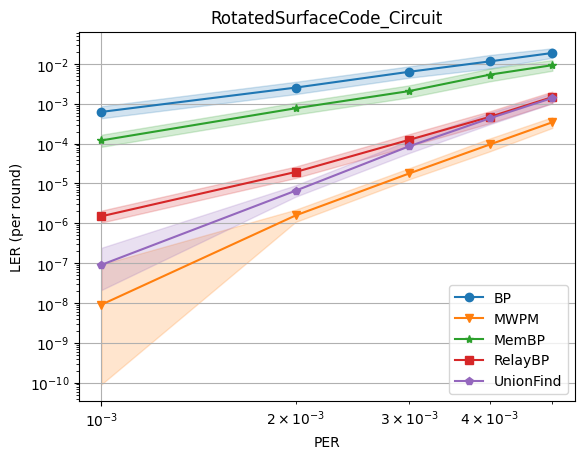

In [16]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=cmp_stats,
    group_func=lambda stat: f"{stat.json_metadata['decoder']}",
    failure_units_per_shot_func=lambda _: circuit_params["rounds"],
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per round)")
ax.set_xlabel("PER")
ax.set_title(f"{circuit_name}")
ax.legend()

plt.show()